# Soft Actor-Critic (SAC): Maximum-Entropy Reinforcement Learning

**A hands-on tutorial with theory and PyTorch implementation**

---

**Soft Actor-Critic** ([Haarnoja et al., 2018a](https://arxiv.org/abs/1801.01290),
[2018b](https://arxiv.org/abs/1812.05905)) changed the objective of reinforcement learning itself. Instead of
maximizing expected return alone, a SAC agent maximizes return **plus the entropy of its policy** — it is rewarded
for acting as randomly as possible while still succeeding. This one change fixes several of DDPG's problems at once:
exploration becomes principled and state-dependent, the policy is robust to perturbations, and training is remarkably
stable across tasks and seeds. SAC quickly became the standard off-policy algorithm for continuous control and was
the first deep RL method to train real robots (a quadruped walking, dexterous manipulation) in hours.

## What you will learn

1. The **maximum-entropy RL objective** and why it helps.
2. **Soft** value functions, the soft Bellman equation, and soft policy iteration.
3. The **squashed Gaussian** policy, the **reparameterization trick**, and the tanh log-probability correction.
4. **Automatic temperature tuning**: learning $\alpha$ from an entropy constraint.
5. A **from-scratch PyTorch implementation** on `Pendulum-v1`.
6. How SAC relates to DDPG/TD3, soft Q-learning and modern practice.

## Notebook outline

1. The maximum-entropy objective
2. Soft policy iteration
3. The stochastic actor
4. Automatic temperature tuning
5. Implementation
6. Training on Pendulum
7. **Visual demonstration** of the trained agent
8. Strengths, weaknesses & connections
9. References

## 0. Setup

We use PyTorch for function approximation, `gymnasium` (the maintained fork of OpenAI Gym) for environments,
`pygame` for rendering frames, and `imageio` to turn rendered frames into GIFs. If you don't have these installed,
uncomment the install cell.

In [1]:
# !pip install torch gymnasium pygame imageio matplotlib numpy

In [2]:
import math
import random
import time
import warnings
from collections import deque
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")   # noisy pygame import warning

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}, gymnasium version: {gym.__version__}")

Using device: cpu
PyTorch version: 2.11.0, gymnasium version: 1.2.3


### Visualization helpers

Every tutorial in this folder ends with a *visual demonstration* of the trained agent. The three helpers below are
shared across notebooks:

- `record_episode` rolls out one episode with a given action function and collects rendered RGB frames.
- `show_filmstrip` shows a handful of evenly spaced frames as a static image (renders everywhere, including GitHub).
- `save_gif` writes an animated GIF to `media/` and displays it inline.

In [3]:
import os
import imageio.v3 as iio
from IPython.display import Image, display

MEDIA_DIR = "media"
os.makedirs(MEDIA_DIR, exist_ok=True)


def record_episode(env, act_fn, seed=0, max_steps=1000):
    """Roll out one episode in an env created with render_mode="rgb_array".

    `act_fn(obs) -> action`. Returns (frames, episode_return, episode_length).
    """
    obs, _ = env.reset(seed=seed)
    frames, ep_ret = [env.render()], 0.0
    for _ in range(max_steps):
        obs, reward, terminated, truncated, _ = env.step(act_fn(obs))
        ep_ret += reward
        frames.append(env.render())
        if terminated or truncated:
            break
    return frames, ep_ret, len(frames) - 1


def show_filmstrip(frames, n=8, title=None, captions=None):
    """Static preview: n evenly spaced frames side by side."""
    idx = np.linspace(0, len(frames) - 1, num=min(n, len(frames)), dtype=int)
    h, w = np.asarray(frames[0]).shape[:2]
    fw = 2.3
    fig, axes = plt.subplots(1, len(idx), figsize=(fw * len(idx), fw * h / w + 0.6))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(frames[i])
        ax.axis("off")
        ax.set_title(captions[i] if captions is not None else f"t = {i}", fontsize=9)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def save_gif(frames, name, fps=30, max_frames=240, downscale=2):
    """Subsample/downscale frames, write media/<name>.gif and return an inline Image."""
    step = max(1, int(np.ceil(len(frames) / max_frames)))
    small = np.stack([np.asarray(f)[::downscale, ::downscale] for f in frames[::step]])
    path = os.path.join(MEDIA_DIR, f"{name}.gif")
    iio.imwrite(path, small, duration=int(1000 * step / fps), loop=0)
    print(f"Saved {path}  ({small.shape[0]} frames, {os.path.getsize(path) / 1e6:.2f} MB)")
    return Image(filename=path)

## 1. The Maximum-Entropy Objective

Standard RL maximizes $\mathbb{E}\big[\sum_t \gamma^t r_t\big]$. Maximum-entropy RL adds the policy's entropy at every
visited state, weighted by a **temperature** $\alpha$:

$$
\boxed{\;J(\pi) \;=\; \mathbb{E}_{\tau \sim \pi}\Big[\sum_{t} \gamma^t \big(\, r_t + \alpha\, \mathcal{H}\big(\pi(\cdot \mid s_t)\big)\big)\Big], \qquad \mathcal{H}(\pi(\cdot|s)) = -\mathbb{E}_{a \sim \pi}[\log \pi(a|s)]\;}
$$

Why would we *want* a random policy?

- **Exploration is built in.** The agent is paid to keep its options open, in proportion to $\alpha$; there is no
  hand-designed noise process. Crucially, the amount of randomness is *state-dependent*: high where actions don't
  matter, low where precision is needed.
- **Multi-modality.** If two actions are equally good, a max-entropy policy takes both, rather than arbitrarily
  committing. This preserves useful behaviors that can be refined later (e.g. when the task changes).
- **Robustness.** Policies trained with entropy are less sensitive to model errors and perturbations — an argument
  made rigorous via connections to robust control.
- **Optimization is smoother.** The entropy term regularizes the policy, which helps avoid premature collapse to bad
  deterministic policies — a frequent DDPG failure mode.

Entropy-regularized RL has a long history (Ziebart's maximum-entropy IRL, 2008; Todorov's linearly-solvable MDPs;
soft Q-learning, 2017). SAC made it practical for continuous control with an off-policy actor-critic.

## 2. Soft Policy Iteration

With the entropy term, the value functions become **soft**:

$$
Q^\pi(s,a) = r(s,a) + \gamma\, \mathbb{E}_{s'}\big[V^\pi(s')\big], \qquad
V^\pi(s) = \mathbb{E}_{a \sim \pi}\big[Q^\pi(s,a) - \alpha \log \pi(a|s)\big].
$$

The **soft Bellman backup** used to train the critic is therefore

$$
\boxed{\;y \;=\; r + \gamma\,(1-d)\,\Big(\min_{i=1,2} Q_{\phi_i^-}(s', a') \;-\; \alpha \log \pi_\theta(a' \mid s')\Big), \qquad a' \sim \pi_\theta(\cdot \mid s')\;}
$$

Note that $a'$ is sampled from the **current** policy at $s'$ (not stored in the buffer), and that SAC uses TD3's
**twin critics with a minimum** to counter over-estimation.

For the policy, the soft policy improvement step is to make $\pi$ proportional to $\exp(Q/\alpha)$, projected onto the
policy family via KL divergence. For a parametric policy this amounts to minimizing

$$
\boxed{\;J_\pi(\theta) \;=\; \mathbb{E}_{s \sim \mathcal{D},\, a \sim \pi_\theta}\Big[\, \alpha \log \pi_\theta(a|s) \;-\; \min_{i} Q_{\phi_i}(s,a)\,\Big]\;}
$$

i.e. take actions with high $Q$ *and* keep entropy high. Haarnoja et al. proved that alternating soft policy evaluation
and soft policy improvement converges to the optimal max-entropy policy in the tabular case; SAC is the
function-approximation version with a single gradient step for each.

In the limit $\alpha \to 0$ the soft objectives reduce to the usual ones and SAC becomes a stochastic cousin of TD3.

## 3. The Stochastic Actor

### 3.1 Squashed Gaussian

The policy outputs a state-dependent Gaussian in an unbounded pre-action space and squashes it with $\tanh$ to
respect the action bounds:

$$
u \sim \mathcal{N}\big(\mu_\theta(s), \sigma_\theta(s)^2\big), \qquad a = a_{\max} \tanh(u).
$$

Because $\tanh$ is a change of variables, the log-density of $a$ needs a Jacobian correction:

$$
\log \pi(a|s) \;=\; \log \mathcal{N}(u; \mu, \sigma) \;-\; \sum_{i} \log\big(1 - \tanh^2(u_i)\big).
$$

This term is easy to forget and is essential — without it the entropy is computed for the wrong distribution.

### 3.2 The reparameterization trick

$J_\pi$ contains an expectation over $a \sim \pi_\theta$, and we need its gradient with respect to $\theta$. Rather than
the high-variance score-function (REINFORCE) estimator, SAC **reparameterizes** the sample,
$u = \mu_\theta(s) + \sigma_\theta(s) \odot \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, I)$, so that the action is
a differentiable function of $\theta$ and the gradient can flow through the critic:
$\nabla_\theta J_\pi = \mathbb{E}\big[\nabla_\theta\big(\alpha \log\pi_\theta(a|s) - Q(s,a)\big)\big|_{a = f_\theta(\varepsilon, s)}\big]$.
This is the same pathway as DDPG's deterministic policy gradient, plus noise.

## 4. Automatic Temperature Tuning

The temperature $\alpha$ sets the trade-off between reward and entropy, and its right value depends on the reward
scale and on how far training has progressed. The second SAC paper (Haarnoja et al., 2018b) reframes the problem as
**constrained** optimization: maximize return subject to the policy entropy being at least a target $\bar{\mathcal{H}}$.
The dual of that constraint gives a simple update for $\alpha$:

$$
\boxed{\;J(\alpha) \;=\; \mathbb{E}_{a \sim \pi}\big[-\alpha \log\pi(a|s) - \alpha \bar{\mathcal{H}}\big]\;}
$$

Gradient descent on $J(\alpha)$ *increases* $\alpha$ when the policy's entropy is below the target (to push it to explore
more) and *decreases* $\alpha$ when entropy is above it. The default target $\bar{\mathcal{H}} = -\dim(\mathcal{A})$
works almost universally. We optimize $\log\alpha$ to keep $\alpha > 0$.

### The SAC algorithm (one step)

1. Act by sampling $a \sim \pi_\theta(\cdot|s)$; store the transition.
2. Sample a minibatch. Critic step: regress both $Q_{\phi_i}$ onto the soft target $y$.
3. Actor step: one gradient step on $J_\pi(\theta)$ with reparameterized actions.
4. Temperature step: one gradient step on $J(\alpha)$.
5. Soft-update the target critics.

## 5. Implementation

### 5.1 Hyperparameters

In [4]:
@dataclass
class SACConfig:
    env_id: str = "Pendulum-v1"
    total_timesteps: int = 25_000
    learning_starts: int = 2_000
    buffer_size: int = 100_000
    batch_size: int = 256
    gamma: float = 0.99
    tau: float = 0.005
    actor_lr: float = 3e-4
    critic_lr: float = 3e-4
    alpha_lr: float = 3e-4
    hidden: int = 256
    init_alpha: float = 0.2
    autotune: bool = True             # learn alpha from the entropy constraint
    target_entropy_scale: float = 1.0 # target entropy = -scale * act_dim
    eval_interval: int = 1_000
    eval_episodes: int = 5


cfg = SACConfig()
print(cfg)

SACConfig(env_id='Pendulum-v1', total_timesteps=25000, learning_starts=2000, buffer_size=100000, batch_size=256, gamma=0.99, tau=0.005, actor_lr=0.0003, critic_lr=0.0003, alpha_lr=0.0003, hidden=256, init_alpha=0.2, autotune=True, target_entropy_scale=1.0, eval_interval=1000, eval_episodes=5)


### 5.2 Squashed-Gaussian actor and twin critics

`Actor.sample` returns the action, its log-probability (with the tanh correction) and the deterministic mean action
(used for evaluation). `LOG_STD` bounds keep the Gaussian well-behaved early in training.

In [5]:
LOG_STD_MIN, LOG_STD_MAX = -5.0, 2.0


class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, act_limit, hidden=256):
        super().__init__()
        self.trunk = nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU())
        self.mu_head = nn.Linear(hidden, act_dim)
        self.log_std_head = nn.Linear(hidden, act_dim)
        self.act_limit = act_limit

    def forward(self, obs):
        h = self.trunk(obs)
        return self.mu_head(h), self.log_std_head(h).clamp(LOG_STD_MIN, LOG_STD_MAX)

    def sample(self, obs):
        mu, log_std = self(obs)
        std = log_std.exp()
        dist = torch.distributions.Normal(mu, std)
        u = dist.rsample()                          # reparameterized: mu + std * eps
        a = torch.tanh(u)
        # log pi(a|s) = log N(u; mu, std) - sum log(1 - tanh(u)^2)
        log_prob = dist.log_prob(u).sum(-1) - torch.log(1 - a.pow(2) + 1e-6).sum(-1)
        return self.act_limit * a, log_prob, self.act_limit * torch.tanh(mu)


class TwinCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        make = lambda: nn.Sequential(nn.Linear(obs_dim + act_dim, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1))
        self.q1, self.q2 = make(), make()

    def forward(self, obs, act):
        x = torch.cat([obs, act], -1)
        return self.q1(x).squeeze(-1), self.q2(x).squeeze(-1)


class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim):
        self.capacity, self.ptr, self.size = capacity, 0, 0
        self.obs = np.zeros((capacity, obs_dim), np.float32); self.next_obs = np.zeros((capacity, obs_dim), np.float32)
        self.act = np.zeros((capacity, act_dim), np.float32); self.rew = np.zeros(capacity, np.float32); self.done = np.zeros(capacity, np.float32)
    def add(self, o, a, r, o2, d):
        i = self.ptr; self.obs[i], self.act[i], self.rew[i], self.next_obs[i], self.done[i] = o, a, r, o2, d
        self.ptr = (self.ptr + 1) % self.capacity; self.size = min(self.size + 1, self.capacity)
    def sample(self, n):
        idx = np.random.randint(0, self.size, n); f = lambda x: torch.as_tensor(x[idx], device=device)
        return f(self.obs), f(self.act), f(self.rew), f(self.next_obs), f(self.done)


def soft_update(target, source, tau):
    with torch.no_grad():
        for p_t, p in zip(target.parameters(), source.parameters()):
            p_t.mul_(1 - tau).add_(tau * p)

### 5.3 The SAC update

Three optimizers, three losses: critic, actor, temperature. Compare with the equations in sections 2 and 4.

In [6]:
def sac_update(actor, critic, critic_targ, log_alpha, opts, batch, cfg, target_entropy):
    obs, act, rew, next_obs, done = batch
    alpha = log_alpha.exp().detach()

    # ---- critic: soft Bellman target with fresh actions from the current policy ----
    with torch.no_grad():
        next_act, next_logp, _ = actor.sample(next_obs)
        q1_t, q2_t = critic_targ(next_obs, next_act)
        target = rew + cfg.gamma * (1 - done) * (torch.min(q1_t, q2_t) - alpha * next_logp)
    q1, q2 = critic(obs, act)
    critic_loss = F.mse_loss(q1, target) + F.mse_loss(q2, target)
    opts["critic"].zero_grad(); critic_loss.backward(); opts["critic"].step()

    # ---- actor: minimize E[ alpha * log pi(a|s) - min_i Q_i(s, a) ], a reparameterized ----
    new_act, logp, _ = actor.sample(obs)
    q1_pi, q2_pi = critic(obs, new_act)
    actor_loss = (alpha * logp - torch.min(q1_pi, q2_pi)).mean()
    opts["actor"].zero_grad(); actor_loss.backward(); opts["actor"].step()

    # ---- temperature: minimize E[ -alpha * (log pi + target_entropy) ] ----
    if cfg.autotune:
        alpha_loss = -(log_alpha.exp() * (logp.detach() + target_entropy)).mean()
        opts["alpha"].zero_grad(); alpha_loss.backward(); opts["alpha"].step()

    soft_update(critic_targ, critic, cfg.tau)
    return dict(critic_loss=critic_loss.item(), actor_loss=actor_loss.item(), alpha=log_alpha.exp().item(),
                entropy=-logp.mean().item(), q=torch.min(q1_pi, q2_pi).mean().item())

### 5.4 Training loop

Exploration is simply sampling from the policy — no noise process. For evaluation we use the mean action.

In [7]:
def evaluate(actor, env_id, n_episodes=5, seed=10_000, deterministic=True):
    env = gym.make(env_id); rets = []
    for i in range(n_episodes):
        o, _ = env.reset(seed=seed + i); done, R = False, 0.0
        while not done:
            with torch.no_grad():
                a, _, a_mean = actor.sample(torch.as_tensor(o, dtype=torch.float32, device=device))
            o, r, term, trunc, _ = env.step((a_mean if deterministic else a).cpu().numpy()); R += r; done = term or trunc
        rets.append(R)
    env.close(); return float(np.mean(rets))


def train_sac(cfg: SACConfig, seed=SEED, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env = gym.make(cfg.env_id); env = gym.wrappers.RecordEpisodeStatistics(env)
    obs_dim, act_dim, act_limit = env.observation_space.shape[0], env.action_space.shape[0], float(env.action_space.high[0])
    actor = Actor(obs_dim, act_dim, act_limit, cfg.hidden).to(device)
    critic, critic_targ = TwinCritic(obs_dim, act_dim, cfg.hidden).to(device), TwinCritic(obs_dim, act_dim, cfg.hidden).to(device)
    critic_targ.load_state_dict(critic.state_dict())
    log_alpha = torch.tensor(math.log(cfg.init_alpha), device=device, requires_grad=True)
    opts = dict(actor=torch.optim.Adam(actor.parameters(), lr=cfg.actor_lr),
                critic=torch.optim.Adam(critic.parameters(), lr=cfg.critic_lr),
                alpha=torch.optim.Adam([log_alpha], lr=cfg.alpha_lr))
    target_entropy = -cfg.target_entropy_scale * act_dim
    buffer = ReplayBuffer(cfg.buffer_size, obs_dim, act_dim)

    logs = dict(train_returns=[], train_steps=[], eval_steps=[], eval_returns=[], stats=[], stat_steps=[])
    best_ret, best_state = -np.inf, None
    o, _ = env.reset(seed=seed); env.action_space.seed(seed)
    for step in range(1, cfg.total_timesteps + 1):
        if step <= cfg.learning_starts:
            a = env.action_space.sample()
        else:
            with torch.no_grad():
                a = actor.sample(torch.as_tensor(o, dtype=torch.float32, device=device))[0].cpu().numpy()
        o2, r, term, trunc, info = env.step(a)
        buffer.add(o, a, r, o2, float(term)); o = o2
        if term or trunc:
            logs["train_returns"].append(float(info["episode"]["r"])); logs["train_steps"].append(step); o, _ = env.reset()

        if step > cfg.learning_starts:
            stats = sac_update(actor, critic, critic_targ, log_alpha, opts, buffer.sample(cfg.batch_size), cfg, target_entropy)
            if step % 100 == 0:
                logs["stats"].append(stats); logs["stat_steps"].append(step)

        if step % cfg.eval_interval == 0:
            ret = evaluate(actor, cfg.env_id, cfg.eval_episodes)
            logs["eval_steps"].append(step); logs["eval_returns"].append(ret)
            if ret >= best_ret:
                best_ret, best_state = ret, {k: v.clone() for k, v in actor.state_dict().items()}
            if verbose and logs["stats"]:
                s = logs["stats"][-1]
                print(f"step {step:6d} | eval return {ret:8.1f} | alpha {s['alpha']:.3f} | policy entropy {s['entropy']:6.2f} | Q {s['q']:7.1f}")
    env.close()
    best_actor = Actor(obs_dim, act_dim, act_limit, cfg.hidden).to(device); best_actor.load_state_dict(best_state)
    return actor, best_actor, critic, logs

## 6. Training on Pendulum

In [8]:
t0 = time.time()
actor, best_actor, critic, logs = train_sac(cfg)
print(f"\nTrained in {time.time() - t0:.0f}s. Best eval return: {max(logs['eval_returns']):.1f}")

step   3000 | eval return  -1500.7 | alpha 0.158 | policy entropy  -0.32 | Q   -31.7


step   4000 | eval return   -768.2 | alpha 0.140 | policy entropy  -0.78 | Q   -59.1


step   5000 | eval return   -129.5 | alpha 0.143 | policy entropy  -1.12 | Q   -72.9


step   6000 | eval return   -126.0 | alpha 0.163 | policy entropy  -1.33 | Q   -79.2


step   7000 | eval return   -124.5 | alpha 0.163 | policy entropy  -1.05 | Q   -81.5


...

step  21000 | eval return    -96.6 | alpha 0.062 | policy entropy  -0.94 | Q   -34.4


step  22000 | eval return    -96.6 | alpha 0.057 | policy entropy  -0.97 | Q   -42.6


step  23000 | eval return    -96.6 | alpha 0.051 | policy entropy  -0.86 | Q   -42.5


step  24000 | eval return    -97.3 | alpha 0.045 | policy entropy  -1.22 | Q   -47.2


step  25000 | eval return    -96.8 | alpha 0.040 | policy entropy  -0.87 | Q   -38.8

Trained in 105s. Best eval return: -96.1


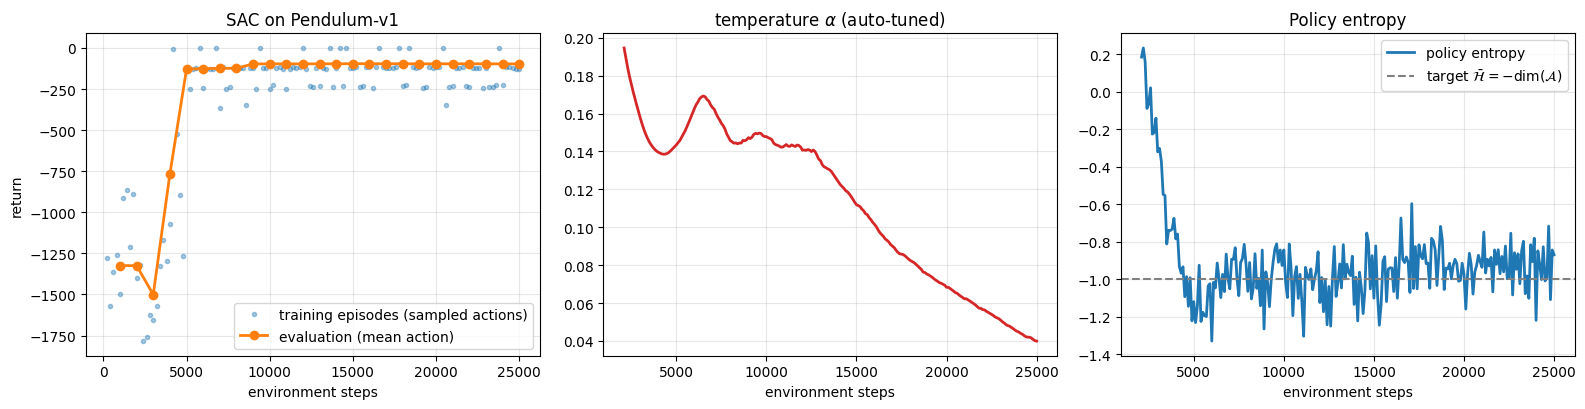

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(logs["train_steps"], logs["train_returns"], ".", alpha=0.4, label="training episodes (sampled actions)")
axes[0].plot(logs["eval_steps"], logs["eval_returns"], "o-", lw=2, label="evaluation (mean action)")
axes[0].set_xlabel("environment steps"); axes[0].set_ylabel("return"); axes[0].set_title("SAC on Pendulum-v1"); axes[0].legend(); axes[0].grid(alpha=0.3)
st = logs["stat_steps"]
axes[1].plot(st, [s["alpha"] for s in logs["stats"]], lw=2, color="C3")
axes[1].set_xlabel("environment steps"); axes[1].set_title(r"temperature $\alpha$ (auto-tuned)"); axes[1].grid(alpha=0.3)
axes[2].plot(st, [s["entropy"] for s in logs["stats"]], lw=2, label="policy entropy")
axes[2].axhline(-1.0, color="gray", ls="--", label=r"target $\bar{\mathcal{H}} = -\dim(\mathcal{A})$")
axes[2].set_xlabel("environment steps"); axes[2].set_title("Policy entropy"); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the plots.** SAC solves Pendulum in roughly the same number of steps as TD3. The middle and right panels show
the entropy constraint at work: the policy starts random (entropy above the target), the constraint pulls the entropy
down to the target $\bar{\mathcal{H}} = -1$ within a few thousand steps, and it then hovers there for the rest of
training. Meanwhile $\alpha$ keeps decreasing: as the critic sharpens, a smaller and smaller entropy bonus suffices to
keep the policy from collapsing below the target. No noise schedule was ever specified.

### 6.1 State-dependent exploration

Because the policy's standard deviation is a function of the state, we can look at *where* the agent chooses to be
random. Below: the mean torque and the standard deviation of the policy over the pendulum's state space.

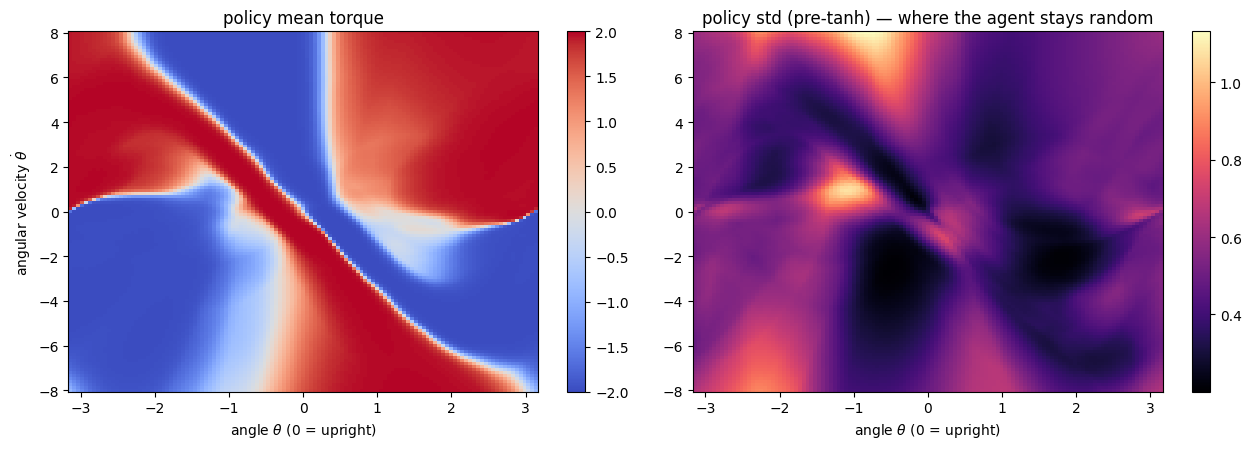

In [10]:
thetas = np.linspace(-np.pi, np.pi, 121); vels = np.linspace(-8, 8, 121)
TH, VEL = np.meshgrid(thetas, vels)
states = torch.as_tensor(np.stack([np.cos(TH), np.sin(TH), VEL], -1).reshape(-1, 3), dtype=torch.float32, device=device)
with torch.no_grad():
    mu, log_std = best_actor(states)
    mean_act = (best_actor.act_limit * torch.tanh(mu)).cpu().numpy().reshape(TH.shape)
    std = log_std.exp().cpu().numpy().reshape(TH.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
im = axes[0].pcolormesh(TH, VEL, mean_act, shading="auto", cmap="coolwarm", vmin=-2, vmax=2); plt.colorbar(im, ax=axes[0])
axes[0].set_title("policy mean torque"); axes[0].set_xlabel(r"angle $\theta$ (0 = upright)"); axes[0].set_ylabel(r"angular velocity $\dot\theta$")
im = axes[1].pcolormesh(TH, VEL, std, shading="auto", cmap="magma"); plt.colorbar(im, ax=axes[1])
axes[1].set_title("policy std (pre-tanh) — where the agent stays random"); axes[1].set_xlabel(r"angle $\theta$ (0 = upright)")
plt.tight_layout(); plt.show()

Typically the policy is most deterministic near the upright equilibrium (where precision matters) and along the
swing-up trajectory, and most random in regions it rarely visits or where the torque hardly matters.

## 7. Visual Demonstration

We show the deterministic (mean-action) policy. Try `deterministic=False` in `evaluate` to see that the *stochastic*
policy is nearly as good — a property that DDPG/TD3 policies with added noise do not share.

Best actor — mean action : -107.3
Best actor — sampled     : -107.8


Returns of 5 recorded episodes (different start angles): [-123, 0, -116, -227, -236]; showing the median one (-123.0)


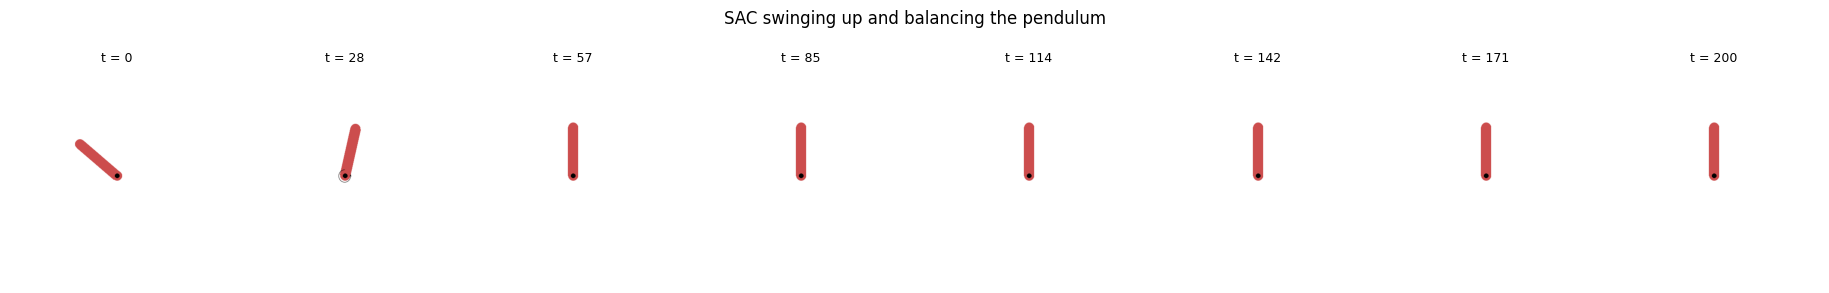

In [11]:
print(f"Best actor — mean action : {evaluate(best_actor, cfg.env_id, 10, seed=555, deterministic=True):.1f}")
print(f"Best actor — sampled     : {evaluate(best_actor, cfg.env_id, 10, seed=555, deterministic=False):.1f}")

def act_mean(obs):
    with torch.no_grad():
        return best_actor.sample(torch.as_tensor(obs, dtype=torch.float32, device=device))[2].cpu().numpy()

render_env = gym.make(cfg.env_id, render_mode="rgb_array")
episodes = [record_episode(render_env, act_mean, seed=s, max_steps=200) for s in range(5)]
render_env.close()
frames, ep_ret, ep_len = sorted(episodes, key=lambda e: e[1])[len(episodes) // 2]   # the median-return episode of 5
print(f"Returns of 5 recorded episodes (different start angles): {[round(e[1]) for e in episodes]}; showing the median one ({ep_ret:.1f})")
show_filmstrip(frames, n=8, title="SAC swinging up and balancing the pendulum")

Saved media/sac_pendulum.gif  (201 frames, 0.04 MB)


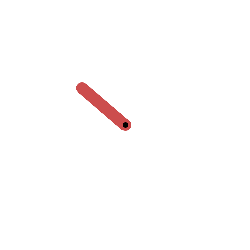

In [12]:
save_gif(frames, "sac_pendulum", fps=25)

## 8. Strengths, Weaknesses & Connections

### Strengths

- **Stable and robust.** SAC works across a wide range of tasks with the same hyperparameters; it is far less
  seed-sensitive than DDPG and at least as good as TD3, often better on hard exploration problems.
- **Principled exploration** with no noise schedule, and a stochastic policy that is useful at deployment
  (e.g. for robustness or for multi-modal tasks).
- **Sample-efficient** off-policy learning; the go-to choice for real-robot learning.

### Weaknesses

- **Continuous actions only** in its original form (a discrete variant exists but is less compelling than DQN-family methods).
- **More moving parts**: two critics, a stochastic actor with the tanh correction, a temperature optimizer.
- **Compute per step** is higher than TD3 (an extra actor forward pass for the target, and sampling).
- **The entropy target** is a heuristic; the max-entropy objective changes the optimal policy, which is sometimes
  undesirable (a stochastic policy is not always what you want).

### Connections

- **DDPG / TD3**: same architecture (replay, twin critics, Polyak targets); SAC replaces the deterministic actor with a
  max-entropy stochastic one and additive noise with entropy.
- **Soft Q-learning** (Haarnoja et al., 2017): the value-based max-entropy predecessor with an energy-based policy.
- **Maximum-entropy IRL** (Ziebart et al., 2008) and **control as inference** (Levine, 2018): the theoretical framing
  in which max-entropy RL is exact inference in a graphical model.
- **PPO's entropy bonus** is the on-policy, ad-hoc cousin of the entropy term; **RLHF**'s KL-to-reference penalty is a
  relative-entropy version of it.
- **Modern practice**: DrQ, DrQ-v2, REDQ, DroQ, RLPD and most model-based methods (MBPO, Dreamer's actor) use
  SAC-style actors and critics. SAC remains the default off-policy baseline in continuous control.

## 9. References

1. **Haarnoja, T., Zhou, A., Abbeel, P., & Levine, S.** (2018a). *Soft actor-critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor.* ICML. [[pdf]](https://arxiv.org/abs/1801.01290)
2. **Haarnoja, T., Zhou, A., Hartikainen, K., Tucker, G., Ha, S., Tan, J., Kumar, V., Zhu, H., Gupta, A., Abbeel, P., & Levine, S.** (2018b). *Soft actor-critic algorithms and applications.* arXiv:1812.05905.
3. **Haarnoja, T., Tang, H., Abbeel, P., & Levine, S.** (2017). *Reinforcement learning with deep energy-based policies.* ICML (soft Q-learning).
4. **Ziebart, B. D., Maas, A., Bagnell, J. A., & Dey, A. K.** (2008). *Maximum entropy inverse reinforcement learning.* AAAI.
5. **Levine, S.** (2018). *Reinforcement learning and control as probabilistic inference: Tutorial and review.* arXiv:1805.00909.
6. **Fujimoto, S., van Hoof, H., & Meger, D.** (2018). *Addressing function approximation error in actor-critic methods.* ICML (TD3).
7. **Achiam, J.** (2018). *Spinning Up in Deep RL — Soft Actor-Critic.* [[docs]](https://spinningup.openai.com/en/latest/algorithms/sac.html)